In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,27-12-2012,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,24-07-2011,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,23-09-2014,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,10/10/2013,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,30-10-2014,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,5/8/2014,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,"Jul 11, 2011",Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,28-12-2011,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,11/8/2013,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [6]:
sales_by_yearly_quarter = df.groupby(
    [
        df['Order Date'].dt.year.rename('Year'),
        df['Order Date'].dt.quarter.rename('Quarter')
    ]
    
)[['Sales']].agg(
    total_sales = ('Sales','sum')
).round(2)
sales_by_yearly_quarter

total_sales
Year Quarter             
2011 1          355969.24
     2          489911.51
     3          616933.03
     4          799829.38
2012 1          412871.02
     2          625538.03
     3          739767.18
     4          902136.34
2013 1          579216.52
     2          831839.27
     3          928271.80
     4         1075086.26
2014 1          706738.37
     2          957454.75
     3         1184954.10
     4         1458739.97

In [7]:
sales_by_yearly_quarter[['total_sales']]

total_sales
Year Quarter             
2011 1          355969.24
     2          489911.51
     3          616933.03
     4          799829.38
2012 1          412871.02
     2          625538.03
     3          739767.18
     4          902136.34
2013 1          579216.52
     2          831839.27
     3          928271.80
     4         1075086.26
2014 1          706738.37
     2          957454.75
     3         1184954.10
     4         1458739.97

In [8]:
sales_by_yearly_quarter_backup = sales_by_yearly_quarter

In [9]:
sales_by_yearly_quarter.reset_index(inplace=True)

In [10]:
sales_by_yearly_quarter

,Year,Quarter,total_sales
0,2011,1,355969.24
1,2011,2,489911.51
2,2011,3,616933.03
3,2011,4,799829.38
4,2012,1,412871.02
5,2012,2,625538.03
6,2012,3,739767.18
7,2012,4,902136.34
8,2013,1,579216.52
9,2013,2,831839.27


In [11]:
sales_by_yearly_quarter['order_date'] = pd.to_datetime(sales_by_yearly_quarter['Year'].astype(str)+ '-' + sales_by_yearly_quarter['Quarter'].astype(str), format='%Y-%m')

In [12]:
sales_by_yearly_quarter

,Year,Quarter,total_sales,order_date
0,2011,1,355969.24,2011-01-01
1,2011,2,489911.51,2011-02-01
2,2011,3,616933.03,2011-03-01
3,2011,4,799829.38,2011-04-01
4,2012,1,412871.02,2012-01-01
5,2012,2,625538.03,2012-02-01
6,2012,3,739767.18,2012-03-01
7,2012,4,902136.34,2012-04-01
8,2013,1,579216.52,2013-01-01
9,2013,2,831839.27,2013-02-01


In [13]:
sales_by_yearly_quarter['Quarter'] = sales_by_yearly_quarter['Quarter'].case_when(
    [
        (sales_by_yearly_quarter['Quarter'] == 1, 'Q1'),
        (sales_by_yearly_quarter['Quarter'] == 2, 'Q2'),
        (sales_by_yearly_quarter['Quarter'] == 3, 'Q3'),
        (sales_by_yearly_quarter['Quarter'] == 4, 'Q4')
    ]
).astype(str)

In [14]:
sales_by_yearly_quarter

,Year,Quarter,total_sales,order_date
0,2011,Q1,355969.24,2011-01-01
1,2011,Q2,489911.51,2011-02-01
2,2011,Q3,616933.03,2011-03-01
3,2011,Q4,799829.38,2011-04-01
4,2012,Q1,412871.02,2012-01-01
5,2012,Q2,625538.03,2012-02-01
6,2012,Q3,739767.18,2012-03-01
7,2012,Q4,902136.34,2012-04-01
8,2013,Q1,579216.52,2013-01-01
9,2013,Q2,831839.27,2013-02-01


In [15]:
sales_by_yearly_quarter.set_index(keys='order_date',inplace=True)

In [18]:
sales_by_yearly_quarter

,Year,Quarter,total_sales
order_date,,,
2011-01-01,2011,Q1,355969.24
2011-02-01,2011,Q2,489911.51
2011-03-01,2011,Q3,616933.03
2011-04-01,2011,Q4,799829.38
2012-01-01,2012,Q1,412871.02
2012-02-01,2012,Q2,625538.03
2012-03-01,2012,Q3,739767.18
2012-04-01,2012,Q4,902136.34
2013-01-01,2013,Q1,579216.52


In [21]:
sales_by_yearly_quarter.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 16 entries, 2011-01-01 to 2014-04-01
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         16 non-null     int32  
 1   Quarter      16 non-null     str    
 2   total_sales  16 non-null     float64
dtypes: float64(1), int32(1), str(1)
memory usage: 448.0 bytes


In [23]:
sales_by_yearly_quarter['Year'] = sales_by_yearly_quarter['Year'].astype(str)

In [25]:
sales_by_yearly_quarter['Quarterly'] = sales_by_yearly_quarter['Year'] + sales_by_yearly_quarter['Quarter']

In [26]:
sales_by_yearly_quarter

,Year,Quarter,total_sales,Quarterly
order_date,,,,
2011-01-01,2011,Q1,355969.24,2011Q1
2011-02-01,2011,Q2,489911.51,2011Q2
2011-03-01,2011,Q3,616933.03,2011Q3
2011-04-01,2011,Q4,799829.38,2011Q4
2012-01-01,2012,Q1,412871.02,2012Q1
2012-02-01,2012,Q2,625538.03,2012Q2
2012-03-01,2012,Q3,739767.18,2012Q3
2012-04-01,2012,Q4,902136.34,2012Q4
2013-01-01,2013,Q1,579216.52,2013Q1


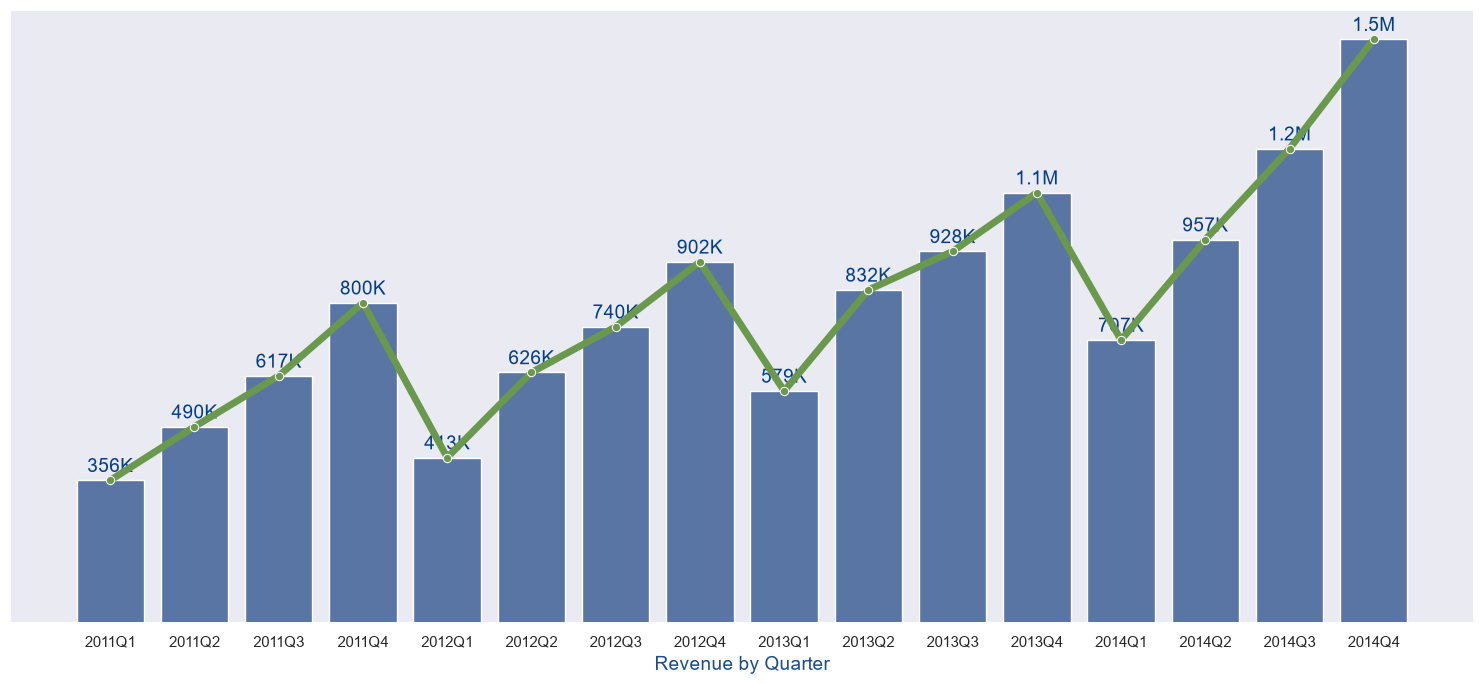

In [74]:
from matplotlib.ticker import FuncFormatter
def format_currency(value, pos):
    if value >= 1_000_000_000:
        return f'{value/1_000_000_000:.1f}B'
    elif value >= 1_000_000:
        return f'{value/1_000_000:.1f}M'
    elif value >= 1_000:
        return f'{value/1_000:.0f}K'
    else:
        return f'{value:.0f}'

sns.set_theme()

ax0, ax1 = plt.subplots(figsize=(15,7))

sns.barplot(
    data=sales_by_yearly_quarter,
    x='Quarterly',
    y='total_sales',
    ax=ax1
)
ax1.yaxis.set_visible(False)
ax1.grid(False)
ax1.bar_label(
    ax1.containers[0],
    labels=[format_currency(v, None) for v in sales_by_yearly_quarter['total_sales']],
    padding=3,
    fontsize=14,
    color='#023e8a'
)
ax1.set_xlabel('Revenue by Quarter',color='#1d4e89', fontsize='14')

ax2 = ax1.twinx()
sns.lineplot(
    data=sales_by_yearly_quarter,
    x='Quarterly',
    y='total_sales',
    ax=ax2,
    lw=5,
    color='#6a994e',
    marker='o'
)
ax2.grid(False)
ax2.yaxis.set_visible(False)

ax2.set_ylim(ax1.get_ylim())
ax0.tight_layout()

#removes unecessary text/label on top of the chart
ax1.yaxis.get_offset_text().set_visible(False)
ax2.yaxis.get_offset_text().set_visible(False)


In [62]:
# Business Question 3:
# Are there specific months or quarters that exhibit strong seasonal spikes in revenue?

# Answer:
# Every 4th Quarter shows a massive spike on gains. Highly likely, Christmas and Thanksgiving season plays a big role considering people were expect
# to gather indoors or outdoors and spend their hard earned money during this last quarter to the year.